# Notebook 02 - Exploratory Data Analysis
## Project: Graph-Aware Explainable AI for AML Detection
### Module: UMADXD-60-M, UWE Bristol

**Purpose:** Explore the IBM AMLworld HI-Small dataset before modelling.  
**Key questions:**
- What does the class imbalance look like visually?
- How are transaction amounts distributed across illicit vs legitimate?
- What is the temporal coverage of the dataset?

**Kernel:** graphaml (Python 3.11)  
**Author:** Charan Rajashekar  


In [1]:
# Imports and reproducibility seed
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import random
import os

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Display settings
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid")

print("Libraries loaded")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

Libraries loaded
Pandas version: 2.2.3
Numpy version: 1.26.4


In [2]:
# Load raw data
df = pd.read_csv("../data/raw/HI-Small_Trans.csv")

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Total transactions: {len(df):,}")
print(f"Illicit transactions: {df['Is Laundering'].sum():,}")
print(f"Illicit rate: {df['Is Laundering'].mean()*100:.3f}%")

Shape: (5078345, 11)
Columns: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']
Total transactions: 5,078,345
Illicit transactions: 5,177
Illicit rate: 0.102%


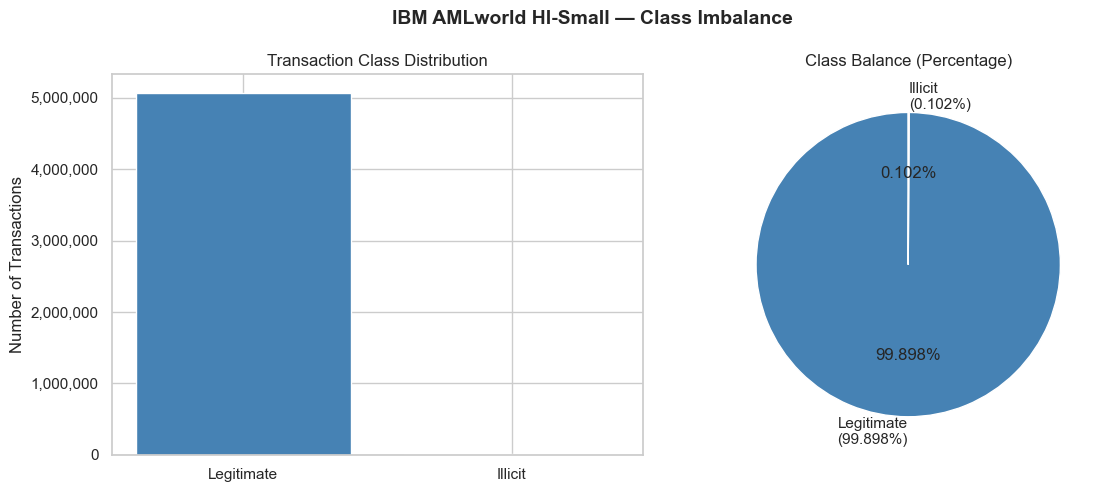

Figure saved to outputs/


In [3]:
#Class imbalance visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
class_counts = df['Is Laundering'].value_counts()
axes[0].bar(['Legitimate', 'Illicit'], 
            class_counts.values,
            color=['steelblue', 'crimson'])
axes[0].set_title('Transaction Class Distribution')
axes[0].set_ylabel('Number of Transactions')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Percentage plot
axes[1].pie([class_counts[0], class_counts[1]],
            labels=['Legitimate\n(99.898%)', 'Illicit\n(0.102%)'],
            colors=['steelblue', 'crimson'],
            autopct='%1.3f%%',
            startangle=90)
axes[1].set_title('Class Balance (Percentage)')

plt.suptitle('IBM AMLworld HI-Small — Class Imbalance', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/fig01_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to outputs/")

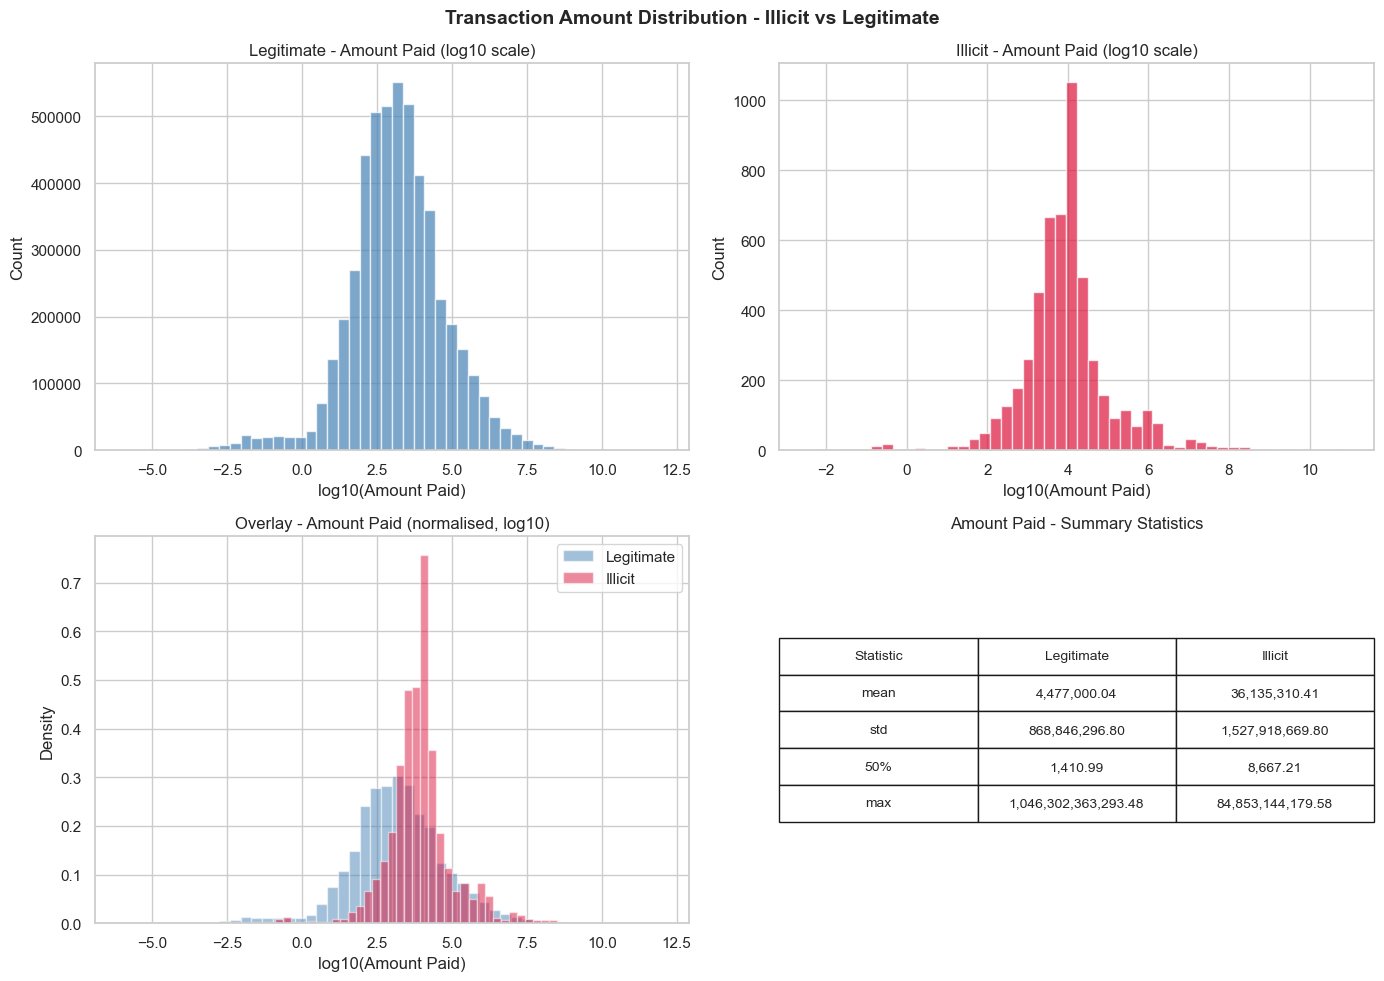

Figure saved to outputs/


In [4]:
# Transaction amount distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Log-scale distributions for legitimate vs illicit
for idx, label, color, name in [(0, 0, 'steelblue', 'Legitimate'), 
                                  (1, 1, 'crimson', 'Illicit')]:
    subset = df[df['Is Laundering'] == label]['Amount Paid']
    
    axes[0, idx].hist(np.log10(subset[subset > 0]), 
                      bins=50, color=color, alpha=0.7, edgecolor='white')
    axes[0, idx].set_title(f'{name} - Amount Paid (log10 scale)')
    axes[0, idx].set_xlabel('log10(Amount Paid)')
    axes[0, idx].set_ylabel('Count')

# Overlay comparison
for label, color, name in [(0, 'steelblue', 'Legitimate'), 
                            (1, 'crimson', 'Illicit')]:
    subset = df[df['Is Laundering'] == label]['Amount Paid']
    axes[1, 0].hist(np.log10(subset[subset > 0]),
                    bins=50, color=color, alpha=0.5, 
                    label=name, edgecolor='white', density=True)
axes[1, 0].set_title('Overlay - Amount Paid (normalised, log10)')
axes[1, 0].set_xlabel('log10(Amount Paid)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

# Summary statistics table as text
stats = df.groupby('Is Laundering')['Amount Paid'].describe()
axes[1, 1].axis('off')
table_data = [['Statistic', 'Legitimate', 'Illicit']]
for stat in ['mean', 'std', '50%', 'max']:
    table_data.append([
        stat,
        f"{stats.loc[0, stat]:,.2f}",
        f"{stats.loc[1, stat]:,.2f}"
    ])
table = axes[1, 1].table(cellText=table_data[1:],
                          colLabels=table_data[0],
                          loc='center', cellLoc='center')
table.scale(1, 2)
axes[1, 1].set_title('Amount Paid - Summary Statistics')

plt.suptitle('Transaction Amount Distribution - Illicit vs Legitimate',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/fig02_amount_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to outputs/")

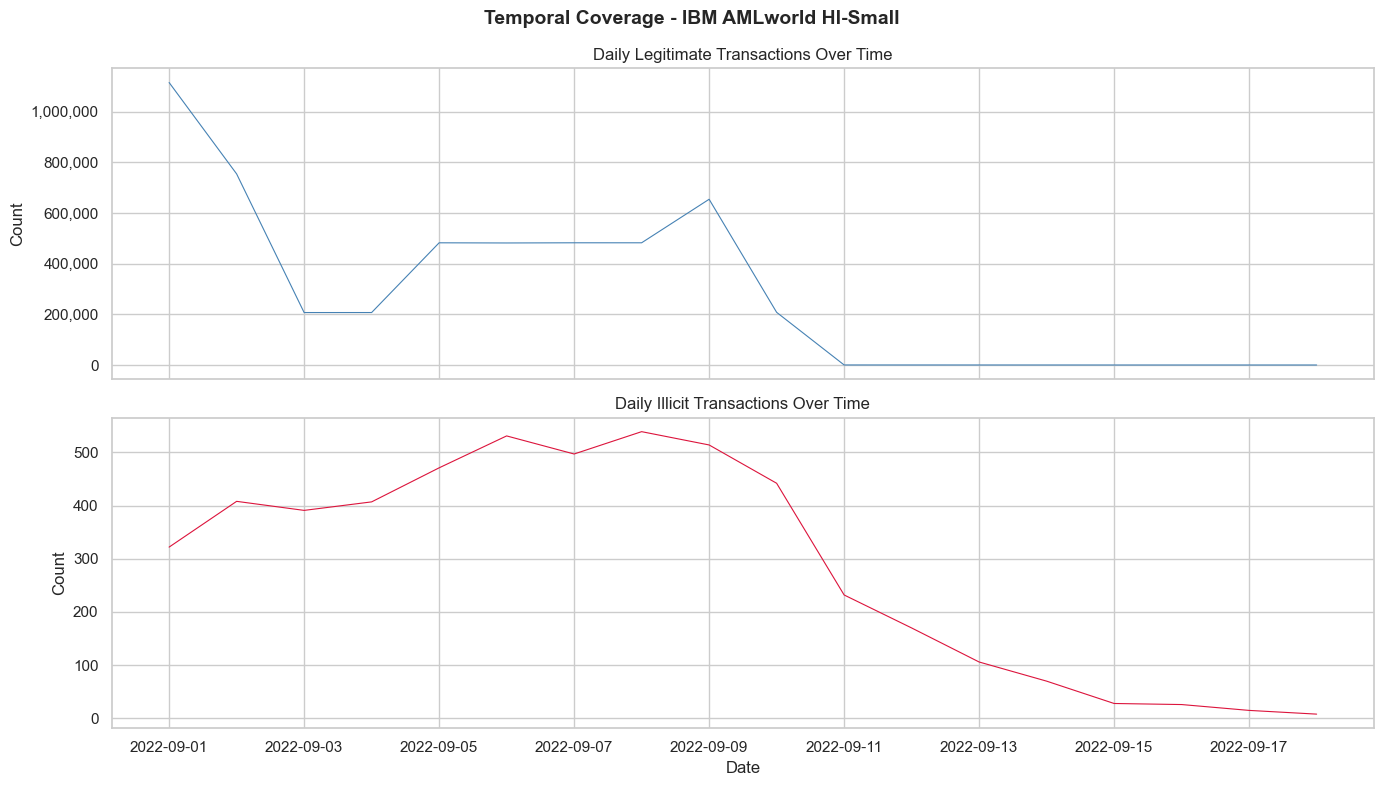

Dataset start: 2022-09-01 00:00:00
Dataset end:   2022-09-18 16:18:00
Total days:    17


In [5]:
# Temporal coverage plot
# Parse timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Date'] = df['Timestamp'].dt.date

# Daily transaction counts by class
daily = df.groupby(['Date', 'Is Laundering']).size().unstack(fill_value=0)
daily.columns = ['Legitimate', 'Illicit']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# All transactions over time
axes[0].plot(daily.index, daily['Legitimate'], 
             color='steelblue', linewidth=0.8, label='Legitimate')
axes[0].set_title('Daily Legitimate Transactions Over Time')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Illicit transactions over time
axes[1].plot(daily.index, daily['Illicit'], 
             color='crimson', linewidth=0.8, label='Illicit')
axes[1].set_title('Daily Illicit Transactions Over Time')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Date')

plt.suptitle('Temporal Coverage - IBM AMLworld HI-Small',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/fig03_temporal_coverage.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Print date range
print(f"Dataset start: {df['Timestamp'].min()}")
print(f"Dataset end:   {df['Timestamp'].max()}")
print(f"Total days:    {(df['Timestamp'].max() - df['Timestamp'].min()).days}")

In [6]:
# Summary statistics table
summary = df.groupby('Is Laundering').agg(
    Transaction_Count=('Amount Paid', 'count'),
    Mean_Amount=('Amount Paid', 'mean'),
    Median_Amount=('Amount Paid', 'median'),
    Std_Amount=('Amount Paid', 'std'),
    Min_Amount=('Amount Paid', 'min'),
    Max_Amount=('Amount Paid', 'max'),
    Mean_Amount_Received=('Amount Received', 'mean'),
    Median_Amount_Received=('Amount Received', 'median')
).round(2)

summary.index = ['Legitimate', 'Illicit']
summary.index.name = 'Class'

print("=" * 60)
print("SUMMARY STATISTICS — IBM AMLworld HI-Small")
print("=" * 60)
print(summary.T.to_string())
print("=" * 60)

summary.to_csv('../outputs/summary_statistics.csv')
print("\nSummary saved to outputs/summary_statistics.csv")

SUMMARY STATISTICS — IBM AMLworld HI-Small
Class                     Legitimate       Illicit
Transaction_Count       5.073168e+06  5.177000e+03
Mean_Amount             4.477000e+06  3.613531e+07
Median_Amount           1.410990e+03  8.667210e+03
Std_Amount              8.688463e+08  1.527919e+09
Min_Amount              0.000000e+00  0.000000e+00
Max_Amount              1.046302e+12  8.485314e+10
Mean_Amount_Received    5.957962e+06  3.613531e+07
Median_Amount_Received  1.407510e+03  8.667210e+03

Summary saved to outputs/summary_statistics.csv


In [7]:
# USD-only summary
df_usd = df[df['Payment Currency'] == 'US Dollar']

summary_usd = df_usd.groupby('Is Laundering').agg(
    Transaction_Count=('Amount Paid', 'count'),
    Mean_Amount=('Amount Paid', 'mean'),
    Median_Amount=('Amount Paid', 'median'),
    Std_Amount=('Amount Paid', 'std'),
    Min_Amount=('Amount Paid', 'min'),
    Max_Amount=('Amount Paid', 'max')
).round(2)

summary_usd.index = ['Legitimate', 'Illicit']
summary_usd.index.name = 'Class'

print("=" * 60)
print("SUMMARY STATISTICS - USD transactions only")
print(f"USD rows: {len(df_usd):,} of {len(df):,} total")
print("=" * 60)
print(summary_usd.T.to_string())
print("=" * 60)

summary_usd.to_csv('../outputs/summary_statistics_usd.csv')
print("\nUSD summary saved to outputs/summary_statistics_usd.csv")

SUMMARY STATISTICS - USD transactions only
USD rows: 1,895,172 of 5,078,345 total
Class                Legitimate       Illicit
Transaction_Count  1.893260e+06  1.912000e+03
Mean_Amount        3.668863e+05  6.320006e+05
Median_Amount      9.014800e+02  5.970080e+03
Std_Amount         2.125868e+07  8.283721e+06
Min_Amount         1.000000e-02  2.280000e+00
Max_Amount         1.662061e+10  2.754260e+08

USD summary saved to outputs/summary_statistics_usd.csv


In [8]:
# Illicit ratio by currency
currency_breakdown = df.groupby('Payment Currency').agg(
    Total=('Is Laundering', 'count'),
    Illicit=('Is Laundering', 'sum')
).reset_index()

currency_breakdown['Legitimate'] = (
    currency_breakdown['Total'] - currency_breakdown['Illicit']
)
currency_breakdown['Illicit_Rate_%'] = (
    currency_breakdown['Illicit'] / 
    currency_breakdown['Total'] * 100
).round(3)

currency_breakdown = currency_breakdown.sort_values(
    'Illicit', ascending=False
)

print("=" * 65)
print(" Illicit transaction by ratio ")
print("=" * 65)
print(currency_breakdown[['Payment Currency', 'Total', 
                           'Legitimate', 'Illicit', 
                           'Illicit_Rate_%']].to_string(index=False))
print("=" * 65)

currency_breakdown.to_csv(
    '../outputs/currency_breakdown.csv', index=False
)
print("\nSaved to outputs/currency_breakdown.csv")

 Illicit transaction by ratio 
 Payment Currency   Total  Legitimate  Illicit  Illicit_Rate_%
        US Dollar 1895172     1893260     1912           0.101
             Euro 1168297     1166925     1372           0.117
      Saudi Riyal   89014       88640      374           0.420
      Swiss Franc  234860      234667      193           0.082
             Yuan  213752      213568      184           0.086
            Rupee  190202      190035      167           0.088
              Yen  155209      155054      155           0.100
            Ruble  155178      155045      133           0.086
         UK Pound  180738      180606      132           0.073
  Canadian Dollar  140042      139914      128           0.091
Australian Dollar  136769      136642      127           0.093
           Shekel  192184      192089       95           0.049
     Mexican Peso  110159      110067       92           0.084
      Brazil Real   70703       70646       57           0.081
          Bitcoin  14606

In [9]:
# Temporal tail verification
daily = (df.assign(date=pd.to_datetime(df['Timestamp']).dt.date)
           .groupby(['date', 'Is Laundering'])
           .size()
           .unstack(fill_value=0)
           .rename(columns={0: 'legitimate', 1: 'illicit'}))

daily['illicit_rate_%'] = (daily['illicit'] /
                           (daily['legitimate'] + daily['illicit']) * 100).round(3)

print(daily.to_string())

Is Laundering  legitimate  illicit  illicit_rate_%
date                                              
2022-09-01        1114599      322           0.029
2022-09-02         754041      408           0.054
2022-09-03         206991      391           0.189
2022-09-04         207023      407           0.196
2022-09-05         482179      471           0.098
2022-09-06         481558      531           0.110
2022-09-07         482254      497           0.103
2022-09-08         482234      539           0.112
2022-09-09         653953      514           0.079
2022-09-10         207883      442           0.212
2022-09-11            164      232          58.586
2022-09-12            111      170          60.498
2022-09-13             78      106          57.609
2022-09-14             51       70          57.851
2022-09-15             18       28          60.870
2022-09-16             20       26          56.522
2022-09-17              8       15          65.217
2022-09-18              3      

In [10]:
# Temporal tail: research note
print("Research note - Temporal tail artefact")
print("=" * 60)
print("Sep 01-10: legitimate transactions dominate, illicit rate ~0.10%")
print("Sep 11-18: simulation wind-down detected")
print("  - Legitimate transactions collapse from 207,883 to 164")
print("  - Illicit rate jumps from 0.21% to 58.59% on Sep 11")
print("  - Final day (Sep 18): 72.7% illicit rate")
print()
print("Implications for Split:")
print("  70th percentile boundary falls ~Sep 08-09")
print("  Test set will contain entire wind-down tail")
print("  Expected test illicit rate >> train illicit rate (~0.10%)")
print()
print("Decesion:")
print("  Proceed with 70th percentile split as pre-registered")
print("  Document as known limitation in report and pre-registration")
print("  Flag in validity audit: inflated test metrics are artefact")
print("  not model skill - interpret AUC-ROC conservatively")

Research note - Temporal tail artefact
Sep 01-10: legitimate transactions dominate, illicit rate ~0.10%
Sep 11-18: simulation wind-down detected
  - Legitimate transactions collapse from 207,883 to 164
  - Illicit rate jumps from 0.21% to 58.59% on Sep 11
  - Final day (Sep 18): 72.7% illicit rate

Implications for Split:
  70th percentile boundary falls ~Sep 08-09
  Test set will contain entire wind-down tail
  Expected test illicit rate >> train illicit rate (~0.10%)

Decesion:
  Proceed with 70th percentile split as pre-registered
  Document as known limitation in report and pre-registration
  Flag in validity audit: inflated test metrics are artefact
  not model skill - interpret AUC-ROC conservatively
